In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import linprog
from src.config import INTERVENTIONS, MONTE_CARLO_SIMULATIONS, LIFT_STD_DEV, TOTAL_BUDGET

np.random.seed(42)

In [2]:
rfm = pd.read_csv('../data/processed/rfm_labeled.csv')
rfm.shape

(4338, 5)

In [7]:
def compute_response_probabilty(rfm, interventions):
    """
    Assigns individual response probabilty to each customer based on segment baseline rate and within segment Recency rank.

    Customers with lower Recency(more recent) get higher probability.
    Adjustment range is +/- 50% of baseline rate.
    """

    rfm = rfm.copy()
    rfm['Response_Prob'] = 0.0

    for segment, params in interventions.items():
        mask = rfm['Segment'] == segment
        segment_df = rfm[mask]

        recency_rank = segment_df['Recency'].rank(pct=True)
        adjustment = (1 - recency_rank) * 0.5 * params['baseline_rate']

        rfm.loc[mask, ['Response_Prob']] = params['baseline_rate'] + round(adjustment, 2)

    return rfm


In [8]:
rfm_prob = compute_response_probabilty(rfm, INTERVENTIONS)

print(rfm_prob.groupby('Segment')['Response_Prob'].describe())

            count      mean       std   min   25%   50%   75%   max
Segment                                                            
At-Risk    1193.0  0.061995  0.007489  0.05  0.06  0.06  0.07  0.07
Champions   713.0  0.311711  0.035314  0.25  0.28  0.31  0.34  0.37
Lost       1622.0  0.025012  0.005002  0.02  0.02  0.03  0.03  0.03
Promising   810.0  0.125346  0.015234  0.10  0.11  0.13  0.14  0.15


## Distribution Assumptions

Lift rates are sampled from normal distributions centered on 
assumed means with standard deviation of 0.03. Normal distribution 
is used for transparency and simplicity. A Beta distribution would 
be more theoretically correct for bounded rate parameters as it is 
naturally constrained between 0 and 1. This is a known simplification 
and can be updated when empirical A/B test variance data is available.

In [9]:
def monte_carlo_simluation(rfm_prob, interventions, n_simulation=MONTE_CARLO_SIMULATIONS, lift_std=LIFT_STD_DEV):
    """
    Runs n_simulations iterations of the intervention simulation.
    Each iteration samples lift rates from a normal distribution
    centered on the assumed lift with give standard deviation

    Returns dataframe of simulation ROI per segment across all iterations.
    """

    simulation_results = {segment: [] for segment in interventions.keys()}

    for _ in range(n_simulation):
        for segment, params in interventions.items():
            segment_df = rfm_prob[rfm_prob['Segment'] == segment]
            n_customers = len(segment_df)

            sampled_lift = np.random.normal(
                loc=params['lift_rate'],
                scale=lift_std
            )

            sampled_lift = max(0, sampled_lift)

            treatment_prob = segment_df['Response_Prob'] + sampled_lift
            treatment_prob = treatment_prob.clip(0, 1)

            incremental_conversions = (treatment_prob - segment_df['Response_Prob']).sum()
            incremental_revenue = incremental_conversions * params['avg_order_value']
            campaign_cost = n_customers * params['cost_per_customer']
            roi = ((incremental_revenue - campaign_cost) / campaign_cost) * 100

            simulation_results[segment].append(roi)

    return pd.DataFrame(simulation_results)

In [10]:
mc_results = monte_carlo_simluation(rfm_prob, INTERVENTIONS)

print(mc_results.shape)
print(mc_results.describe().round(2))

(10000, 4)
       Champions  Promising   At-Risk      Lost
count   10000.00   10000.00  10000.00  10000.00
mean     5300.71     446.21   2057.28    246.30
std      1627.08     202.24    544.93    196.71
min      -100.00    -100.00    -58.07   -100.00
25%      4198.65     308.21   1687.16    102.30
50%      5324.30     445.77   2053.48    242.63
75%      6397.87     584.37   2431.64    379.16
max     11319.32    1239.74   4007.81   1161.11


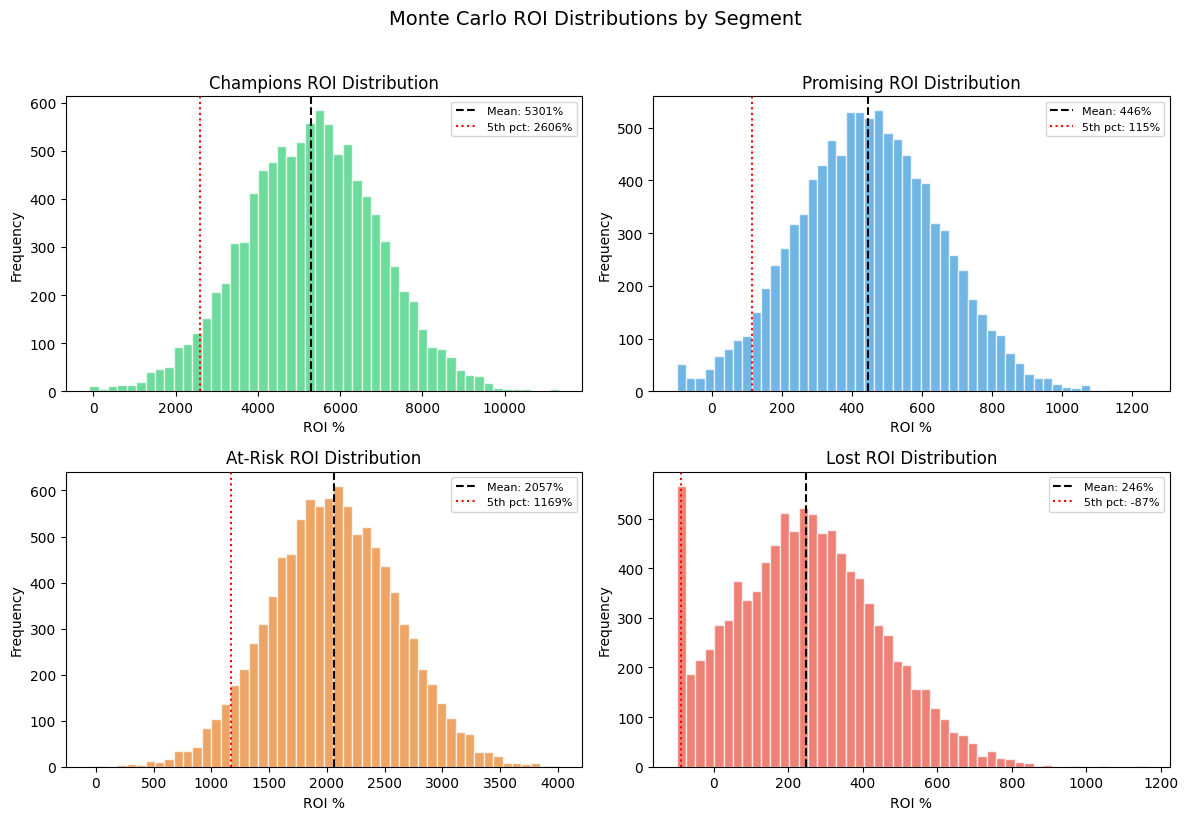

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

segments = list(INTERVENTIONS.keys())
colors = ["#2ecc71", "#3498db", "#e67e22", "#e74c3c"]

for i, (segment, color) in enumerate(zip(segments, colors)):
    axes[i].hist(mc_results[segment], bins=50, color=color, alpha=0.7, edgecolor="white")
    axes[i].axvline(mc_results[segment].mean(), color="black", linestyle="--", linewidth=1.5, label=f"Mean: {mc_results[segment].mean():.0f}%")
    axes[i].axvline(mc_results[segment].quantile(0.05), color="red", linestyle=":", linewidth=1.5, label=f"5th pct: {mc_results[segment].quantile(0.05):.0f}%")
    axes[i].set_title(f"{segment} ROI Distribution")
    axes[i].set_xlabel("ROI %")
    axes[i].set_ylabel("Frequency")
    axes[i].legend(fontsize=8)

plt.suptitle("Monte Carlo ROI Distributions by Segment", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("../outputs/figures/monte_carlo_distributions.png", dpi=150)
plt.show()

In [16]:
ci_table = pd.DataFrame({
    "Segment": segments,
    "Mean ROI %": mc_results.mean().round(1).values,
    "Std Dev": mc_results.std().round(1).values,
    "5th Percentile": mc_results.quantile(0.05).round(1).values,
    "95th Percentile": mc_results.quantile(0.95).round(1).values,
    "Prob Positive ROI": ((mc_results > 0).sum() / len(mc_results) * 100).round(1).values
})

ci_table["Risk Adjusted ROI"] = (ci_table["Mean ROI %"] / ci_table["Std Dev"]).round(2)

ci_table

,Segment,Mean ROI %,Std Dev,5th Percentile,95th Percentile,Prob Positive ROI,Risk Adjusted ROI
0,Champions,5300.7,1627.1,2606.2,7944.9,99.9,3.26
1,Promising,446.2,202.2,115.4,779.5,98.7,2.21
2,At-Risk,2057.3,544.9,1169.3,2954.6,100.0,3.78
3,Lost,246.3,196.7,-86.9,582.4,88.1,1.25


## Risk Adjusted Recommendation

Raw ROI ranking favours Champions at 5,301% mean return. 
However risk adjusted ROI (mean divided by standard deviation, 
analogous to Sharpe ratio) ranks At-Risk highest at 3.78 
versus Champions at 3.26.

At-Risk segment offers the best return per unit of uncertainty: 
100% probability of positive ROI, mean return of 2,057%, and 
the tightest distribution relative to its mean. This makes 
At-Risk reactivation the highest priority intervention under 
risk averse budget allocation.

Lost segment is the weakest investment with 88.1% probability 
of positive ROI and a risk adjusted score of 1.25. Under budget 
constraints Lost should be deprioritised.

In [35]:
segments = list(INTERVENTIONS.keys())

incremental_revenues = []
campaign_costs = []

for segment, params in INTERVENTIONS.items():
    n_customers = len(rfm_prob[rfm_prob['Segment'] == segment])

    mean_lift = params['lift_rate']
    segment_df = rfm_prob[rfm_prob['Segment'] == segment]
    incremental_conv = mean_lift * n_customers                  # For optimization we need a single point statistic which mean of our presumed lift based on consumer analytics studies.
    incremental_rev = round(incremental_conv * params['avg_order_value'], 1)
    cost = n_customers * params['cost_per_customer']

    incremental_revenues.append(incremental_rev)
    campaign_costs.append(cost)

incremental_revenues = np.array(incremental_revenues)
campaign_costs = np.array(campaign_costs)

print("Incremental revenues:", incremental_revenues)
print("Campaign costs:", campaign_costs)
print("Total budget:", TOTAL_BUDGET)
print(f"Full campaign cost: £{sum(campaign_costs):,}")


Incremental revenues: [576531.8  35510.4 257831.2  27736.2]
Campaign costs: [10695  6480 11930  8110]
Total budget: 25000
Full campaign cost: £37,215


In [43]:
c = -incremental_revenues

A_ub = [campaign_costs]
B_ub = [TOTAL_BUDGET]

bounds = [(0, 1)] * len(segments)

result = linprog(
    c=c,
    A_ub=A_ub,
    b_ub=B_ub,
    bounds=bounds,
    method='highs'
)

print('Optimization status', result.message)
print('Segment:         ', segments)
print('Optimal fractions', result.x.round(4))
print(f'Maximum incremental revenue: {-result.fun:,.2f}')


Optimization status Optimization terminated successfully. (HiGHS Status 7: Optimal)
Segment:          ['Champions', 'Promising', 'At-Risk', 'Lost']
Optimal fractions [1.     0.3665 1.     0.    ]
Maximum incremental revenue: 847,378.00


In [45]:
result

        message: Optimization terminated successfully. (HiGHS Status 7: Optimal)
        success: True
         status: 0
            fun: -847378.0
              x: [ 1.000e+00  3.665e-01  1.000e+00  0.000e+00]
            nit: 1
          lower:  residual: [ 1.000e+00  3.665e-01  1.000e+00  0.000e+00]
                 marginals: [ 0.000e+00  0.000e+00  0.000e+00  1.671e+04]
          upper:  residual: [ 0.000e+00  6.335e-01  0.000e+00  1.000e+00]
                 marginals: [-5.179e+05  0.000e+00 -1.925e+05  0.000e+00]
          eqlin:  residual: []
                 marginals: []
        ineqlin:  residual: [ 0.000e+00]
                 marginals: [-5.480e+00]
 mip_node_count: 0
 mip_dual_bound: 0.0
        mip_gap: 0.0

In [50]:
opt_results = pd.DataFrame({
    "Segment": segments,
    "Fraction Targeted": result.x.round(4),
    "Customers Targeted": (result.x * np.array([len(rfm_prob[rfm_prob["Segment"] == s]) 
                          for s in segments])).round(0).astype(int),
    "Budget Allocated": (result.x * campaign_costs).round(2),
    "Expected Revenue": (result.x * incremental_revenues).round(2)
})

opt_results["ROI %"] = ((opt_results["Expected Revenue"] - opt_results["Budget Allocated"]) / 
                         opt_results["Budget Allocated"] * 100).round(1).fillna(0)



opt_results

,Segment,Fraction Targeted,Customers Targeted,Budget Allocated,Expected Revenue,ROI %
0,Champions,1.0000,713,10695.0,576531.8,5290.7
1,Promising,0.3665,297,2375.0,13015.0,448.0
2,At-Risk,1.0000,1193,11930.0,257831.2,2061.2
3,Lost,0.0000,0,0.0,0.0,0.0
